In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
PROJECT_DIR = '/content/drive/MyDrive/cat-breed-ai-project-colab'
%cd $PROJECT_DIR
!ls

/content/drive/MyDrive/cat-breed-ai-project-colab
COLAB_GUIDE.md	dataset_split  PROJECT_CHECKLIST.md  results
dataset_clean	models	       README.md	     scripts
dataset_raw	notebooks      requirements.txt


In [3]:
!pip install -r requirements.txt

In [4]:
!find dataset_raw -mindepth 1 -maxdepth 1 -type d | sort
!find dataset_raw -type f | wc -l

dataset_raw/Abyssinian
dataset_raw/American Bobtail
dataset_raw/American Curl
dataset_raw/American Shorthair
dataset_raw/Bengal
dataset_raw/Birman
dataset_raw/Bombay
dataset_raw/British Shorthair
dataset_raw/Egyptian Mau
dataset_raw/Exotic Shorthair
dataset_raw/Maine Coon
dataset_raw/Manx
dataset_raw/Norwegian Forest
dataset_raw/Persian
dataset_raw/Ragdoll
dataset_raw/Russian Blue
dataset_raw/Scottish Fold
dataset_raw/Siamese
dataset_raw/Sphynx
dataset_raw/Turkish Angora
7000


In [5]:
!rm -rf dataset_clean dataset_split
!python scripts/clean_crawled_images.py --raw-dir dataset_raw --output-dir dataset_clean --target-per-class 1000

cleaning/Abyssinian: 100% 350/350 [00:18<00:00, 19.03it/s]
cleaning/American Bobtail: 100% 350/350 [00:14<00:00, 24.27it/s]
cleaning/American Curl: 100% 350/350 [00:22<00:00, 15.30it/s]
cleaning/American Shorthair: 100% 350/350 [00:15<00:00, 22.75it/s]
cleaning/Bengal: 100% 350/350 [00:16<00:00, 21.67it/s]
cleaning/Birman: 100% 350/350 [00:16<00:00, 21.51it/s]
cleaning/Bombay: 100% 350/350 [00:15<00:00, 22.07it/s]
cleaning/British Shorthair: 100% 350/350 [00:15<00:00, 22.91it/s]
cleaning/Egyptian Mau: 100% 350/350 [00:19<00:00, 17.52it/s]
cleaning/Exotic Shorthair: 100% 350/350 [00:25<00:00, 13.61it/s]
cleaning/Maine Coon: 100% 350/350 [00:18<00:00, 19.08it/s]
cleaning/Manx: 100% 350/350 [00:31<00:00, 11.27it/s]
cleaning/Norwegian Forest: 100% 350/350 [00:18<00:00, 18.61it/s]
cleaning/Persian: 100% 350/350 [00:16<00:00, 21.12it/s]
cleaning/Ragdoll: 100% 350/350 [00:16<00:00, 21.52it/s]
cleaning/Russian Blue: 100% 350/350 [00:18<00:00, 18.99it/s]
cleaning/Scottish Fold: 100% 350/350 [00

In [6]:
import pandas as pd
cleaning_summary = pd.read_csv('dataset_clean/cleaning_summary.csv')
cleaning_summary

,class,raw_candidates,kept,invalid,duplicates
0,Abyssinian,350,349,1,0
1,American Bobtail,350,347,3,0
2,American Curl,350,350,0,0
3,American Shorthair,350,350,0,0
4,Bengal,350,350,0,0
5,Birman,350,347,3,0
6,Bombay,350,347,3,0
7,British Shorthair,350,350,0,0
8,Egyptian Mau,350,348,2,0
9,Exotic Shorthair,350,350,0,0


In [7]:
!python scripts/prepare_dataset.py --raw-dir dataset_clean --output-dir dataset_split --max-classes 20 --min-images-per-class 300

Selected classes:
  american_curl: 350 raw images
  american_shorthair: 350 raw images
  bengal: 350 raw images
  british_shorthair: 350 raw images
  exotic_shorthair: 350 raw images
  manx: 350 raw images
  norwegian_forest: 350 raw images
  persian: 350 raw images
  russian_blue: 350 raw images
  scottish_fold: 350 raw images
  siamese: 350 raw images
  turkish_angora: 350 raw images
  abyssinian: 349 raw images
  maine_coon: 349 raw images
  ragdoll: 349 raw images
  egyptian_mau: 348 raw images
  sphynx: 348 raw images
  american_bobtail: 347 raw images
  birman: 347 raw images
  bombay: 347 raw images
checking/american_curl: 100% 350/350 [00:02<00:00, 156.05it/s]
checking/american_shorthair: 100% 350/350 [00:01<00:00, 218.57it/s]
checking/bengal: 100% 350/350 [00:01<00:00, 284.52it/s]
checking/british_shorthair: 100% 350/350 [00:01<00:00, 245.55it/s]
checking/exotic_shorthair: 100% 350/350 [00:01<00:00, 271.64it/s]
checking/manx: 100% 350/350 [00:01<00:00, 254.36it/s]
checking/nor

In [8]:
summary = pd.read_csv('dataset_split/dataset_summary.csv')
summary

,class,train,val,test,total
0,american_curl,245,52,53,350
1,american_shorthair,245,52,53,350
2,bengal,245,52,53,350
3,british_shorthair,245,52,53,350
4,exotic_shorthair,245,52,53,350
5,manx,245,52,53,350
6,norwegian_forest,245,52,53,350
7,persian,245,52,53,350
8,russian_blue,245,52,53,350
9,scottish_fold,245,52,53,350


In [9]:
print('Total images:', summary['total'].sum())
print('Training images:', summary['train'].sum())
print('Validation images:', summary['val'].sum())
print('Testing images:', summary['test'].sum())

Total images: 6984
Training images: 4884
Validation images: 1040
Testing images: 1060


In [10]:
!python scripts/visualize_dataset.py --dataset-dir dataset_split

Saved dataset visualizations to /content/drive/MyDrive/cat-breed-ai-project-colab/results/graphs


In [11]:
from IPython.display import Image, display

display(Image('results/graphs/dataset_class_distribution.png'))
display(Image('results/graphs/dataset_sample_grid.png'))

Output hidden; open in https://colab.research.google.com to view.

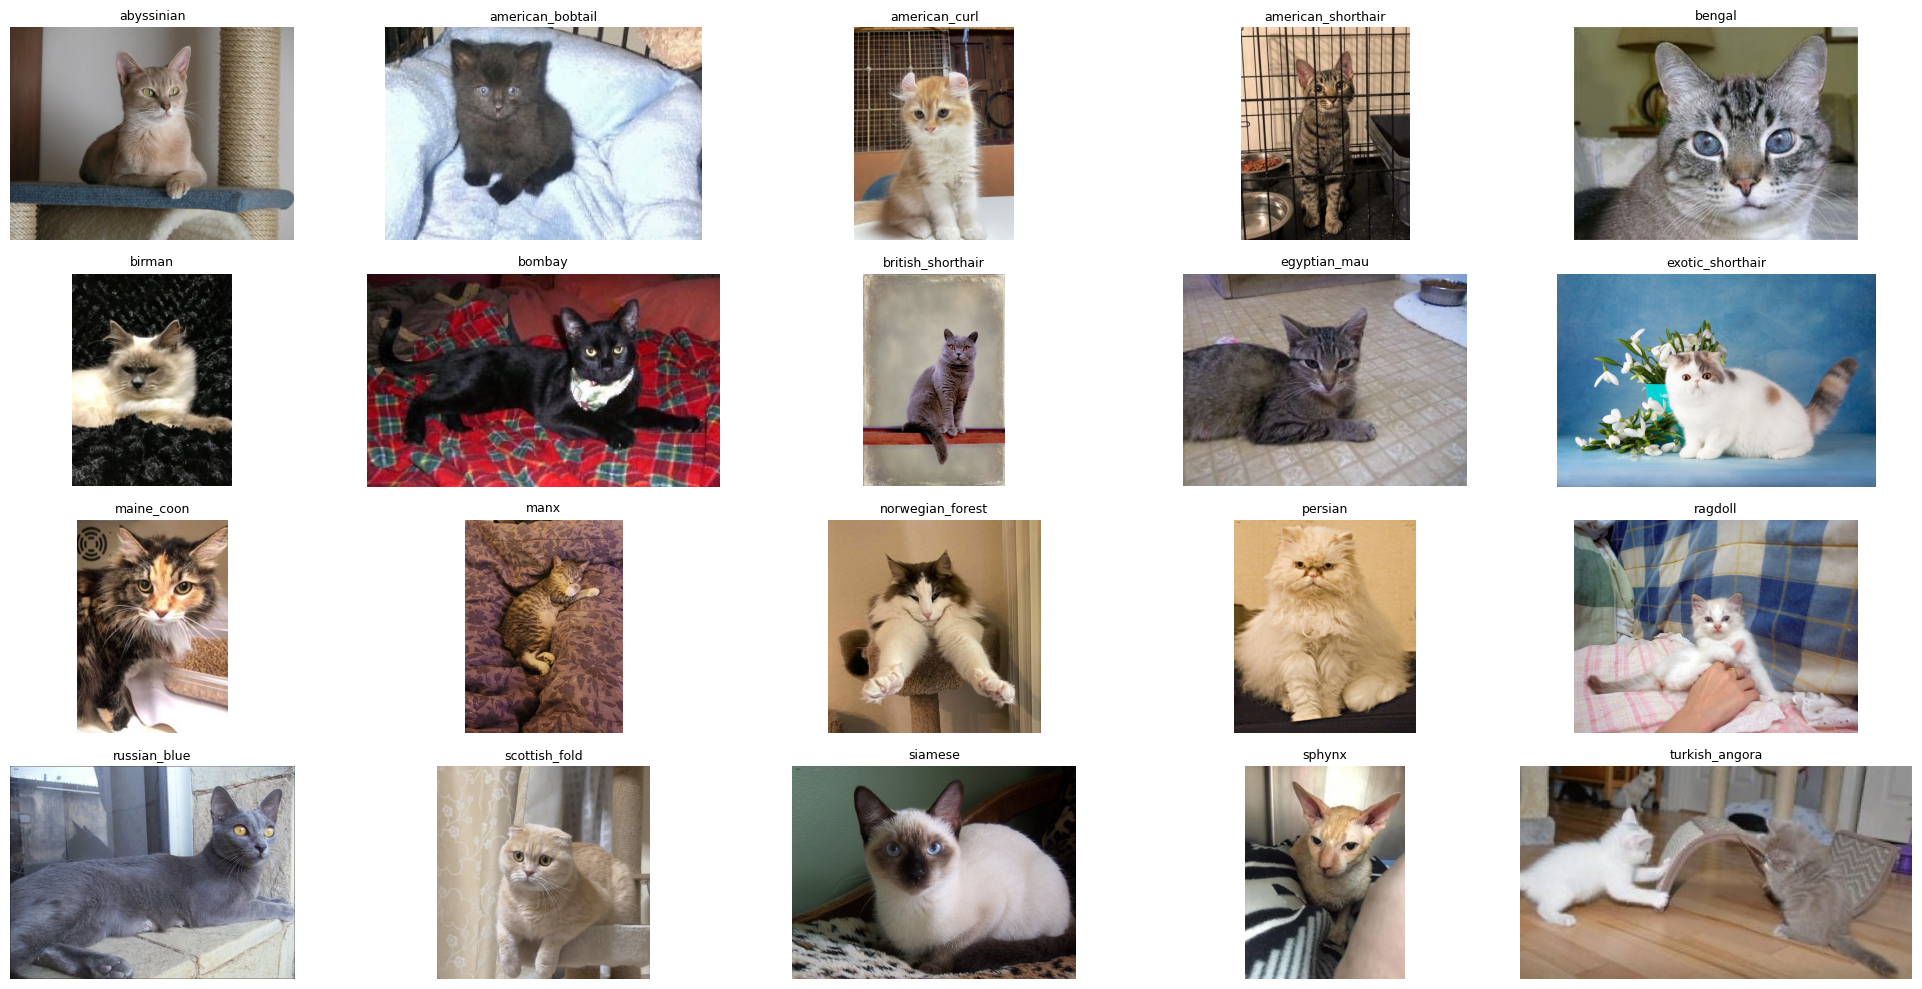

In [12]:
import os
import matplotlib.pyplot as plt
from PIL import Image as PILImage

train_dir = 'dataset_split/train'
class_names = sorted(os.listdir(train_dir))

plt.figure(figsize=(20, 10))
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    image_files = [f for f in os.listdir(class_path) if not f.startswith('.')]
    image_path = os.path.join(class_path, image_files[0])
    img = PILImage.open(image_path).convert('RGB')

    ax = plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.title(class_name, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()